### STEP 1 - IMPORT LIBRARIES

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.feature_selection import (
    SelectKBest,
    chi2
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import pickle

ModuleNotFoundError: No module named 'matplotlib'

### STEP2 LOAD DATA

In [7]:
df = pd.read_csv(r"final_data_set.csv")

In [8]:
print("\nDataset Loaded Successfully\n")

print(df.head())

print("\nDataset Shape\n")

print(df.shape)



Dataset Loaded Successfully

   PROSPECTID  time_since_recent_payment  time_since_first_deliquency  \
0           1                      549.0                         35.0   
1           2                       47.0                          NaN   
2           3                      302.0                         11.0   
3           4                        NaN                          NaN   
4           5                      583.0                          NaN   

   time_since_recent_deliquency  time_since_recent_enq  num_times_delinquent  \
0                          15.0                  566.0                    11   
1                           NaN                  209.0                     0   
2                           3.0                  587.0                     9   
3                           NaN                    NaN                     0   
4                           NaN                 3951.0                     0   

   num_deliq_6mts  num_deliq_12mts  num_deliq_6_12

###  BASIC DATA INFORMATION

In [9]:
print("\nDataset Information\n")

print(df.info())

print("\nMissing Values\n")

print(df.isnull().sum())


Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 96 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PROSPECTID                    51336 non-null  int64  
 1   time_since_recent_payment     47045 non-null  float64
 2   time_since_first_deliquency   15387 non-null  float64
 3   time_since_recent_deliquency  15387 non-null  float64
 4   time_since_recent_enq         45015 non-null  float64
 5   num_times_delinquent          51336 non-null  int64  
 6   num_deliq_6mts                51336 non-null  int64  
 7   num_deliq_12mts               51336 non-null  int64  
 8   num_deliq_6_12mts             51336 non-null  int64  
 9   max_delinquency_level         15387 non-null  float64
 10  max_deliq_6mts                38446 non-null  float64
 11  max_deliq_12mts               40504 non-null  float64
 12  max_recent_level_of_deliq     51336 no

### STEP 3 - CHECK MISSING VALUES

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns

categorical_cols = df.select_dtypes(include='object').columns

# Fill numeric missing values

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values Handled Successfully\n")


Missing Values Handled Successfully



### STEP 4 - REMOVE DUPLICATES

In [11]:

print("Before Removing Duplicates :", df.shape)

df = df.drop_duplicates()

print("After Removing Duplicates  :", df.shape)


Before Removing Duplicates : (51336, 96)
After Removing Duplicates  : (51336, 96)


### STEP 5 - ENCODE CATEGORICAL FEATURES

In [12]:

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("\nCategorical Encoding Completed\n")


NameError: name 'LabelEncoder' is not defined

### STEP 6 -DEFINE FEATURES & TARGET

In [ ]:
X = df.drop('Default_Flag', axis=1)

y = df['Default_Flag']

print("\nFeature Matrix Shape :", X.shape)

print("Target Variable Shape:", y.shape)


Feature Matrix Shape : (51336, 95)
Target Variable Shape: (51336,)


### STEP 8 - FEATURE SCALING

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nFeature Scaling Completed\n")


Feature Scaling Completed



### STEP 9 - FEATURE SELECTION

In [ ]:
selector = SelectKBest(
    score_func=chi2,
    k=20
)

X_selected = selector.fit_transform(
    abs(X_scaled),
    y
)

selected_features = X.columns[
    selector.get_support()
]

print("\nTop Selected Features\n")

for feature in selected_features:
    print(feature)


Top Selected Features

num_std
num_std_6mts
num_std_12mts
pct_of_active_TLs_ever
Total_TL
Tot_Active_TL
Tot_Closed_TL
Total_TL_opened_L6M
Tot_TL_closed_L6M
Total_TL_opened_L12M
Tot_TL_closed_L12M
pct_active_tl
pct_closed_tl
pct_tl_closed_L12M
Tot_Missed_Pmnt
Consumer_TL
Gold_TL
Secured_TL
Unsecured_TL
Other_TL


### STEP 8 - TRAIN TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape\n")

print(X_train.shape)

print("\nTesting Data Shape\n")

print(X_test.shape)



Training Data Shape

(41068, 20)

Testing Data Shape

(10268, 20)


###  STEP 11 - BUILD LOGISTIC REGRESSION MODEL

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed\n")




Model Training Completed



### STEP 10 - TRAIN PREDICTION

In [ ]:
y_train_pred = model.predict(X_train)

y_train_prob = model.predict_proba(X_train)[:,1]

In [ ]:
### TEST PREDICTION
y_test_pred = model.predict(X_test)

y_test_prob = model.predict_proba(X_test)[:,1]

### TRAIN METRICS

In [ ]:
train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

train_precision = precision_score(
    y_train,
    y_train_pred
)

train_recall = recall_score(
    y_train,
    y_train_pred
)

train_f1 = f1_score(
    y_train,
    y_train_pred
)

train_auc = roc_auc_score(
    y_train,
    y_train_prob
)

print("\n================ TRAIN METRICS ================\n")

print("Train Accuracy :", round(train_accuracy,4))

print("Train Precision:", round(train_precision,4))

print("Train Recall   :", round(train_recall,4))

print("Train F1 Score :", round(train_f1,4))

print("Train ROC-AUC  :", round(train_auc,4))


================ TRAIN METRICS ================

Train Accuracy : 0.7107
Train Precision: 0.5622
Train Recall   : 0.6271
Train F1 Score : 0.5929
Train ROC-AUC  : 0.7485


### TEST METRICS

In [ ]:
test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

test_auc = roc_auc_score(
    y_test,
    y_test_prob
)

print("\n================ TEST METRICS ================\n")

print("Test Accuracy :", round(test_accuracy,4))

print("Test Precision:", round(test_precision,4))

print("Test Recall   :", round(test_recall,4))

print("Test F1 Score :", round(test_f1,4))

print("Test ROC-AUC  :", round(test_auc,4))



================ TEST METRICS ================

Test Accuracy : 0.7071
Test Precision: 0.5569
Test Recall   : 0.6267
Test F1 Score : 0.5897
Test ROC-AUC  : 0.7459


###  STEP 16 - CLASSIFICATION REPORT

In [ ]:
print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_test_pred
    )
)


Classification Report

              precision    recall  f1-score   support

           0       0.80      0.75      0.77      6818
           1       0.56      0.63      0.59      3450

    accuracy                           0.71     10268
   macro avg       0.68      0.69      0.68     10268
weighted avg       0.72      0.71      0.71     10268



#### CONFUSION MATRIX

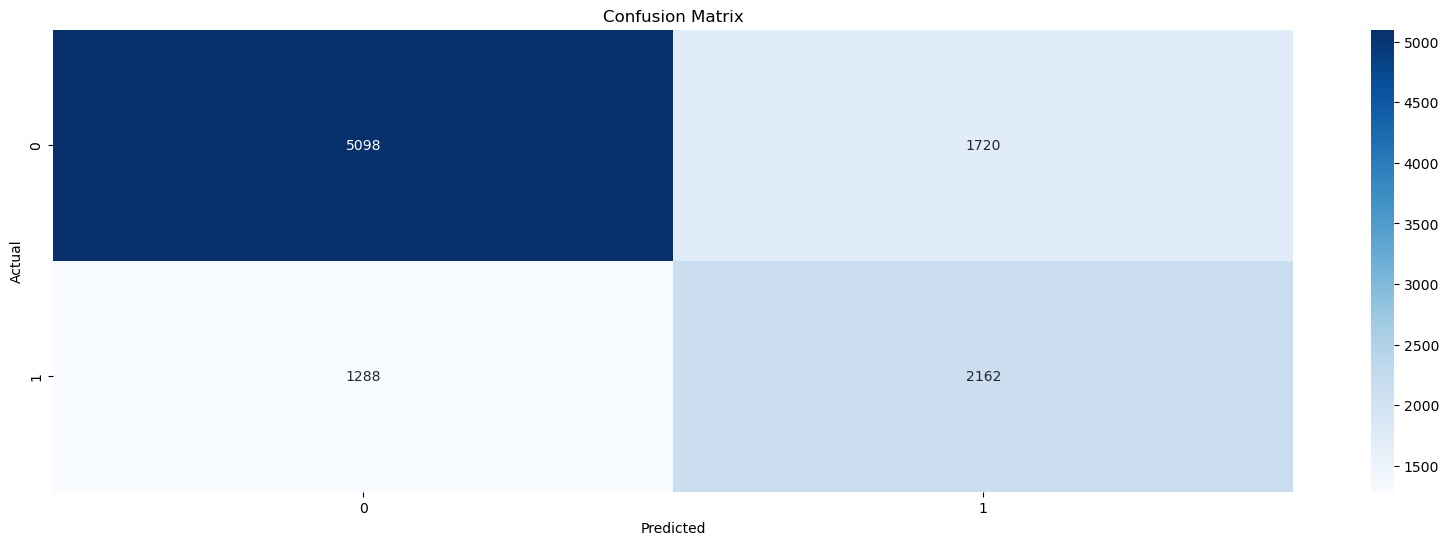

In [ ]:
cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(20,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### ROC AUC SCORE

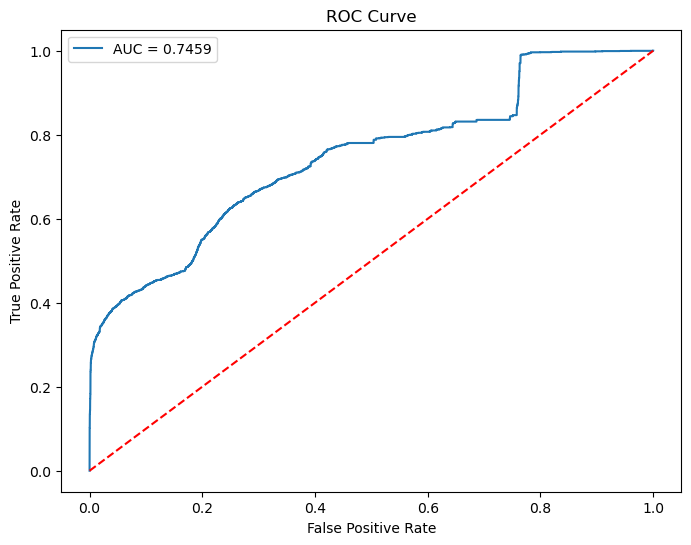

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {round(test_auc,4)}"
)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

### STEP 12 - FEATURE IMPORTANCE

In [ ]:
importance = pd.DataFrame({

    'Feature': selected_features,

    'Coefficient': model.coef_[0]

})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print("\nTop Important Features\n")

print(importance)


Top Important Features

                   Feature  Coefficient
6            Tot_Closed_TL     2.045451
14         Tot_Missed_Pmnt     1.640636
10      Tot_TL_closed_L12M     0.445418
7      Total_TL_opened_L6M     0.377694
5            Tot_Active_TL     0.336307
17              Secured_TL     0.149996
2            num_std_12mts     0.114253
18            Unsecured_TL     0.050639
8        Tot_TL_closed_L6M     0.042338
0                  num_std     0.003812
1             num_std_6mts    -0.004791
15             Consumer_TL    -0.054110
19                Other_TL    -0.134611
9     Total_TL_opened_L12M    -0.237619
12           pct_closed_tl    -0.475100
3   pct_of_active_TLs_ever    -0.475100
11           pct_active_tl    -0.475100
16                 Gold_TL    -0.475564
13      pct_tl_closed_L12M    -0.862627
4                 Total_TL    -1.755021


### STEP 13 - SAVE MODEL

In [ ]:
pickle.dump(
    model,
    open("logistic_model.pkl",'wb')
)

pickle.dump(
    scaler,
    open("scaler.pkl",'wb')
)

print("\nModel Saved Successfully\n")


Model Saved Successfully



### STEP 14 - LOAD MODEL

In [ ]:
loaded_model = pickle.load(
    open("logistic_model.pkl",'rb')
)

print("\nSaved Model Loaded Successfully\n")


Saved Model Loaded Successfully



### FINAL PROJECT STATUS

In [ ]:
print("\nPROJECT COMPLETED SUCCESSFULLY\n")


PROJECT COMPLETED SUCCESSFULLY

